In [4]:
# STEP 1 : Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# Run once in Google Colab before anything else:
# !pip install pyspark openpyxl


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 : Import Libraries
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import StringIndexer
from pyspark.sql.window import Window

In [5]:
# STEP 3 : Read Excel File Using Pandas
# ─────────────────────────────────────────────────────────────────────────────
file_path = "/content/zepto_dataset_v2.xlsx"          # keep exact uploaded file name
df_pd = pd.read_excel(file_path, engine="openpyxl")

print("=" * 60)
print("Pandas DataFrame Shape :", df_pd.shape)
print("=" * 60)
print(df_pd.head(5).to_string())
print("\nColumn Data Types:\n", df_pd.dtypes)

Pandas DataFrame Shape : (120000, 20)
   order_id  customer_id       city    area product_name category  quantity  price_per_unit  discount  delivery_time_minutes  distance_km  delivery_partner_id  warehouse_id payment_method order_status  rating  total_price  final_price          order_time  peak_hour_flag
0         1         1923     Mumbai  Area_E         Milk    Dairy         3              15      0.05                   31.0         5.68                  286             1            UPI    Cancelled     NaN           45        42.75 2025-01-08 22:58:00               1
1         2         5265    Chennai  Area_A     Biscuits   Snacks         2              53      0.22                   28.0         7.58                  391             3            UPI    Delivered     4.4          106        82.68 2025-01-02 19:18:00               1
2         3         2619  Hyderabad  Area_E       Papaya   Fruits         1             115      0.07                   31.0         7.90            

In [6]:
# STEP 4 : Create Spark Session
# ─────────────────────────────────────────────────────────────────────────────
spark = (SparkSession.builder
         .appName("Zepto_Order_Delivery_Demand_Analysis")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("\nSpark Version :", spark.version)


Spark Version : 4.0.2


In [7]:
# STEP 5 : Convert Pandas DataFrame → Spark DataFrame
# ─────────────────────────────────────────────────────────────────────────────
df = spark.createDataFrame(df_pd)
print("\nSpark DataFrame created successfully.")


Spark DataFrame created successfully.


In [8]:
# STEP 6 : Explore Schema, Sample Data, Shape
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Schema ──")
df.printSchema()

print("\n── First 5 Rows ──")
df.show(5, truncate=False)

print(f"\nTotal Rows    : {df.count():,}")
print(f"Total Columns : {len(df.columns)}")
print(f"Column Names  : {df.columns}")



── Schema ──
root
 |-- order_id: long (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- city: string (nullable = true)
 |-- area: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: long (nullable = true)
 |-- price_per_unit: long (nullable = true)
 |-- discount: double (nullable = true)
 |-- delivery_time_minutes: double (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- delivery_partner_id: long (nullable = true)
 |-- warehouse_id: long (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- total_price: long (nullable = true)
 |-- final_price: double (nullable = true)
 |-- order_time: timestamp (nullable = true)
 |-- peak_hour_flag: long (nullable = true)


── First 5 Rows ──
+--------+-----------+---------+------+------------+--------+--------+--------------+--------+---------------------

In [9]:
#  DATA CLEANING
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 : Check Null / Missing Values (before cleaning)
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Null Value Count per Column (Before Cleaning) ──")
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
])
null_counts.show(truncate=False)

total_nulls_before = sum([
    df.filter(F.col(c).isNull()).count() for c in df.columns
])
print(f"Total null cells before cleaning : {total_nulls_before:,}")


── Null Value Count per Column (Before Cleaning) ──
+--------+-----------+----+----+------------+--------+--------+--------------+--------+---------------------+-----------+-------------------+------------+--------------+------------+------+-----------+-----------+----------+--------------+
|order_id|customer_id|city|area|product_name|category|quantity|price_per_unit|discount|delivery_time_minutes|distance_km|delivery_partner_id|warehouse_id|payment_method|order_status|rating|total_price|final_price|order_time|peak_hour_flag|
+--------+-----------+----+----+------------+--------+--------+--------------+--------+---------------------+-----------+-------------------+------------+--------------+------------+------+-----------+-----------+----------+--------------+
|0       |0          |0   |0   |0           |0       |0       |0             |0       |0                    |0          |0                  |0           |0             |0           |0     |0          |0          |0         |0  

In [10]:
# STEP 8 : Check and Remove Duplicate Rows
# ─────────────────────────────────────────────────────────────────────────────
rows_before = df.count()
df = df.dropDuplicates()
rows_after  = df.count()
print(f"\nRows before duplicate removal : {rows_before:,}")
print(f"Rows after  duplicate removal : {rows_after:,}")
print(f"Duplicates removed            : {rows_before - rows_after:,}")


Rows before duplicate removal : 120,000
Rows after  duplicate removal : 120,000
Duplicates removed            : 0


In [11]:
# STEP 9 : Fix Data Types
# ─────────────────────────────────────────────────────────────────────────────
df = df.withColumn("order_time",   F.to_timestamp(F.col("order_time")))
df = df.withColumn("discount",     F.col("discount").cast(DoubleType()))
df = df.withColumn("distance_km",  F.col("distance_km").cast(DoubleType()))
df = df.withColumn("final_price",  F.col("final_price").cast(DoubleType()))
df = df.withColumn("rating",       F.col("rating").cast(DoubleType()))
print("\nData types cast successfully.")
df.printSchema()


Data types cast successfully.
root
 |-- order_id: long (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- city: string (nullable = true)
 |-- area: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: long (nullable = true)
 |-- price_per_unit: long (nullable = true)
 |-- discount: double (nullable = true)
 |-- delivery_time_minutes: double (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- delivery_partner_id: long (nullable = true)
 |-- warehouse_id: long (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- total_price: long (nullable = true)
 |-- final_price: double (nullable = true)
 |-- order_time: timestamp (nullable = true)
 |-- peak_hour_flag: long (nullable = true)



In [12]:
# STEP 10 : Detect and Remove / Cap OUTLIERS
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Outlier Detection ──")

# 11a. Negative price_per_unit → invalid; remove those rows
neg_price_count = df.filter(F.col("price_per_unit") < 0).count()
print(f"Rows with negative price_per_unit  : {neg_price_count}")
df = df.filter(F.col("price_per_unit") > 0)

# 11b. Extreme delivery_time_minutes (> 90 min = outlier for quick commerce)
extreme_del_count = df.filter(F.col("delivery_time_minutes") > 90).count()
print(f"Rows with delivery_time > 90 min   : {extreme_del_count}")
# Cap at 90 (Winsorisation) instead of dropping — retains row, corrects value
df = df.withColumn(
    "delivery_time_minutes",
    F.when(F.col("delivery_time_minutes") > 90, 90)
     .otherwise(F.col("delivery_time_minutes"))
)

# 11c. Extreme quantity (> 15 units per order = bulk/data-entry error)
extreme_qty_count = df.filter(F.col("quantity") > 15).count()
print(f"Rows with quantity > 15 units      : {extreme_qty_count}")
df = df.withColumn(
    "quantity",
    F.when(F.col("quantity") > 15, 15).otherwise(F.col("quantity"))
)

print("Outliers handled (negative prices removed; delivery time & quantity capped).")


── Outlier Detection ──
Rows with negative price_per_unit  : 120
Rows with delivery_time > 90 min   : 2650
Rows with quantity > 15 units      : 360
Outliers handled (negative prices removed; delivery time & quantity capped).


In [13]:
# STEP 11 : Handle Missing / Null Values
# ─────────────────────────────────────────────────────────────────────────────

# Numeric columns: fill with median-like sensible defaults
#   - delivery_time_minutes : fill with city-wise median (group-level imputation)
#   - distance_km           : fill with city-wise median
#   - discount              : fill with category-wise median
#   - rating                : fill with city-wise median (only rated orders)

# 12a. Compute city-level median delivery time using percentile_approx
city_median_del = df.groupBy("city").agg(
    F.percentile_approx("delivery_time_minutes", 0.5).alias("median_del_time")
)
df = (df.join(city_median_del, on="city", how="left")
        .withColumn("delivery_time_minutes",
                    F.coalesce(F.col("delivery_time_minutes"), F.col("median_del_time")))
        .drop("median_del_time"))

# 12b. City-level median distance
city_median_dist = df.groupBy("city").agg(
    F.percentile_approx("distance_km", 0.5).alias("median_dist")
)
df = (df.join(city_median_dist, on="city", how="left")
        .withColumn("distance_km",
                    F.coalesce(F.col("distance_km"), F.col("median_dist")))
        .drop("median_dist"))

# 12c. Category-level median discount
cat_median_disc = df.groupBy("category").agg(
    F.percentile_approx("discount", 0.5).alias("median_disc")
)
df = (df.join(cat_median_disc, on="category", how="left")
        .withColumn("discount",
                    F.coalesce(F.col("discount"), F.col("median_disc")))
        .drop("median_disc"))

# 12d. Rating: fill nulls with city median rating of delivered orders
city_median_rating = (df.filter(F.col("rating").isNotNull())
                        .groupBy("city")
                        .agg(F.percentile_approx("rating", 0.5).alias("median_rating")))
df = (df.join(city_median_rating, on="city", how="left")
        .withColumn("rating",
                    F.coalesce(F.col("rating"), F.col("median_rating")))
        .drop("median_rating"))

# 12e. Categorical nulls
df = df.fillna({"payment_method": "Unknown"})

print("\n── Null Value Count per Column (After Cleaning) ──")
null_counts_after = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
])
null_counts_after.show(truncate=False)
print("Missing values handled successfully.")


── Null Value Count per Column (After Cleaning) ──
+----+--------+--------+-----------+----+------------+--------+--------------+--------+---------------------+-----------+-------------------+------------+--------------+------------+------+-----------+-----------+----------+--------------+
|city|category|order_id|customer_id|area|product_name|quantity|price_per_unit|discount|delivery_time_minutes|distance_km|delivery_partner_id|warehouse_id|payment_method|order_status|rating|total_price|final_price|order_time|peak_hour_flag|
+----+--------+--------+-----------+----+------------+--------+--------------+--------+---------------------+-----------+-------------------+------------+--------------+------------+------+-----------+-----------+----------+--------------+
|0   |0       |0       |0          |0   |0           |0       |0             |0       |0                    |0          |0                  |0           |0             |0           |0     |0          |0          |0         |0   

In [14]:
# STEP 12 : Drop Identifier Columns (not needed for analysis)
# ─────────────────────────────────────────────────────────────────────────────
df_clean = df.drop("order_id", "customer_id", "delivery_partner_id", "warehouse_id")
print("\nColumns in cleaned DataFrame :", df_clean.columns)



Columns in cleaned DataFrame : ['city', 'category', 'area', 'product_name', 'quantity', 'price_per_unit', 'discount', 'delivery_time_minutes', 'distance_km', 'payment_method', 'order_status', 'rating', 'total_price', 'final_price', 'order_time', 'peak_hour_flag']


In [15]:
# STEP 13 : Convert order_status to Numeric (is_delivered)
# ─────────────────────────────────────────────────────────────────────────────
df_clean = df_clean.withColumn(
    "is_delivered",
    F.when(F.col("order_status") == "Delivered", 1).otherwise(0)
)
df_clean.select("order_status", "is_delivered").show(5)

+------------+------------+
|order_status|is_delivered|
+------------+------------+
|   Delivered|           1|
|   Delivered|           1|
|   Delivered|           1|
|   Delivered|           1|
|   Cancelled|           0|
+------------+------------+
only showing top 5 rows


In [16]:
# STEP 14 : Descriptive Statistics
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Descriptive Statistics ──")
df_clean.select(
    "delivery_time_minutes", "distance_km", "price_per_unit",
    "quantity", "discount", "rating", "final_price"
).describe().show()



── Descriptive Statistics ──
+-------+---------------------+-----------+------------------+------------------+--------+------+------------------+
|summary|delivery_time_minutes|distance_km|    price_per_unit|          quantity|discount|rating|       final_price|
+-------+---------------------+-----------+------------------+------------------+--------+------+------------------+
|  count|               119880|     119880|            119880|            119880|  119880|119880|            119880|
|   mean|    31.11836002669336|        NaN|100.32225558892226|2.4326743410076745|     NaN|   NaN|200.39113938938817|
| stddev|   14.273653406583072|        NaN| 56.17263374044872| 1.640905277562753|     NaN|   NaN|151.48235139058315|
|    min|                  8.0|        0.3|                15|                 1|     0.0|   1.0|             10.95|
|    max|                 90.0|        NaN|               405|                15|     NaN|   NaN|           2226.15|
+-------+---------------------+---

In [17]:
#  TRANSFORMATIONS
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# STEP 15 : Transformation 1 – Delivery Speed Category
# ─────────────────────────────────────────────────────────────────────────────
# Zepto promises 10-minute delivery; real-world: Fast ≤20, Normal 21-35, Delayed >35
df_clean = df_clean.withColumn(
    "delivery_speed",
    F.when(F.col("delivery_time_minutes") <= 20, "Fast")
     .when(F.col("delivery_time_minutes") <= 35, "Normal")
     .otherwise("Delayed")
)
print("\n── Transformation 1: Delivery Speed ──")
df_clean.select("delivery_time_minutes", "delivery_speed").show(10, truncate=False)


── Transformation 1: Delivery Speed ──
+---------------------+--------------+
|delivery_time_minutes|delivery_speed|
+---------------------+--------------+
|26.0                 |Normal        |
|30.0                 |Normal        |
|39.0                 |Delayed       |
|24.0                 |Normal        |
|29.0                 |Normal        |
|48.0                 |Delayed       |
|39.0                 |Delayed       |
|25.0                 |Normal        |
|35.0                 |Normal        |
|22.0                 |Normal        |
+---------------------+--------------+
only showing top 10 rows


In [18]:
# Step 16 : Transformation 2 – Discount Tier
# ─────────────────────────────────────────────────────────────────────────────
df_clean = df_clean.withColumn(
    "discount_tier",
    F.when(F.col("discount") < 0.05, "No Discount")
     .when(F.col("discount") < 0.15, "Moderate Discount")
     .otherwise("High Discount")
)
print("\n── Transformation 2: Discount Tier ──")
df_clean.select("discount", "discount_tier").show(10, truncate=False)


── Transformation 2: Discount Tier ──
+--------+-----------------+
|discount|discount_tier    |
+--------+-----------------+
|0.21    |High Discount    |
|0.11    |Moderate Discount|
|0.09    |Moderate Discount|
|0.18    |High Discount    |
|0.16    |High Discount    |
|0.14    |Moderate Discount|
|0.06    |Moderate Discount|
|0.18    |High Discount    |
|0.15    |High Discount    |
|0.19    |High Discount    |
+--------+-----------------+
only showing top 10 rows


In [19]:
# STEP 17 : Transformation 3 – Revenue Band
# ─────────────────────────────────────────────────────────────────────────────
df_clean = df_clean.withColumn(
    "revenue_band",
    F.when(F.col("final_price") < 100, "Low Value")
     .when(F.col("final_price") < 400, "Mid Value")
     .otherwise("High Value")
)
print("\n── Transformation 3: Revenue Band ──")
df_clean.select("final_price", "revenue_band").show(10, truncate=False)

# Combined transformation preview
print("\n── All Three Transformations ──")
df_clean.select(
    "city", "category",
    "delivery_time_minutes", "delivery_speed",
    "discount", "discount_tier",
    "final_price", "revenue_band",
    "is_delivered"
).show(10, truncate=False)


── Transformation 3: Revenue Band ──
+-----------+------------+
|final_price|revenue_band|
+-----------+------------+
|71.1       |Low Value   |
|200.56     |Mid Value   |
|331.08     |Mid Value   |
|190.19     |Mid Value   |
|265.98     |Mid Value   |
|260.76     |Mid Value   |
|72.24      |Low Value   |
|378.4      |Mid Value   |
|207.39     |Mid Value   |
|92.12      |Low Value   |
+-----------+------------+
only showing top 10 rows

── All Three Transformations ──
+---------+---------+---------------------+--------------+--------+-----------------+-----------+------------+------------+
|city     |category |delivery_time_minutes|delivery_speed|discount|discount_tier    |final_price|revenue_band|is_delivered|
+---------+---------+---------------------+--------------+--------+-----------------+-----------+------------+------------+
|Bangalore|Beverages|26.0                 |Normal        |0.11    |Moderate Discount|331.08     |Mid Value   |1           |
|Bangalore|Snacks   |30.0     

In [20]:
# STEP 18 : Encode Categorical Columns → Numeric Index
# ─────────────────────────────────────────────────────────────────────────────
categorical_columns = [
    "city", "area", "category", "product_name",
    "payment_method", "order_status",
    "delivery_speed", "discount_tier", "revenue_band"
]
for col_name in categorical_columns:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_Index",
        handleInvalid="keep"
    )
    df_clean = indexer.fit(df_clean).transform(df_clean)

print("\n── Categorical → Numeric Encoding ──")
df_clean.select(
    "city",          "city_Index",
    "category",      "category_Index",
    "delivery_speed","delivery_speed_Index",
    "discount_tier", "discount_tier_Index"
).show(5, truncate=False)


── Categorical → Numeric Encoding ──
+---------+----------+---------+--------------+--------------+--------------------+-----------------+-------------------+
|city     |city_Index|category |category_Index|delivery_speed|delivery_speed_Index|discount_tier    |discount_tier_Index|
+---------+----------+---------+--------------+--------------+--------------------+-----------------+-------------------+
|Bangalore|2.0       |Beverages|3.0           |Normal        |0.0                 |Moderate Discount|0.0                |
|Bangalore|2.0       |Snacks   |2.0           |Normal        |0.0                 |High Discount    |2.0                |
|Bangalore|2.0       |Dairy    |0.0           |Delayed       |1.0                 |Moderate Discount|0.0                |
|Bangalore|2.0       |Dairy    |0.0           |Normal        |0.0                 |Moderate Discount|0.0                |
|Bangalore|2.0       |Snacks   |2.0           |Delayed       |1.0                 |Moderate Discount|0.0    

In [21]:
#  AGGREGATIONS
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# STEP 19 : Aggregation 1 – City-wise Delivery Performance
# ─────────────────────────────────────────────────────────────────────────────
city_delivery = df_clean.groupBy("city").agg(
    F.round(F.avg("delivery_time_minutes"), 2).alias("avg_delivery_time_min"),
    F.round(F.avg("is_delivered"),          4).alias("delivery_rate"),
    F.round(F.avg("rating"),                2).alias("avg_rating"),
    F.round(F.avg("distance_km"),           2).alias("avg_distance_km"),
    F.count("*").alias("total_orders")
).withColumn(
    "cancellation_rate", F.round(1 - F.col("delivery_rate"), 4)
)
print("\n── Aggregation 1: City-wise Delivery Performance ──")
city_delivery.show(truncate=False)


── Aggregation 1: City-wise Delivery Performance ──
+---------+---------------------+-------------+----------+---------------+------------+-----------------+
|city     |avg_delivery_time_min|delivery_rate|avg_rating|avg_distance_km|total_orders|cancellation_rate|
+---------+---------------------+-------------+----------+---------------+------------+-----------------+
|Bangalore|30.64                |0.8697       |NaN       |NaN            |24131       |0.1303           |
|Delhi    |38.63                |0.8095       |NaN       |NaN            |28880       |0.1905           |
|Chennai  |27.63                |0.891        |NaN       |NaN            |15468       |0.109            |
|Mumbai   |23.83                |0.9127       |NaN       |NaN            |30954       |0.0873           |
|Hyderabad|34.74                |0.8391       |NaN       |NaN            |20447       |0.1609           |
+---------+---------------------+-------------+----------+---------------+------------+------------

In [22]:
# STEP 20 : Aggregation 2 – Category-wise Demand & Revenue
# ─────────────────────────────────────────────────────────────────────────────
category_demand = df_clean.groupBy("category").agg(
    F.sum("quantity").alias("total_units_sold"),
    F.round(F.sum("final_price"),  2).alias("total_revenue"),
    F.round(F.avg("discount"),     3).alias("avg_discount"),
    F.round(F.avg("final_price"),  2).alias("avg_order_value"),
    F.count("*").alias("total_orders")
)
print("\n── Aggregation 2: Category-wise Demand & Revenue ──")
category_demand.show(truncate=False)


── Aggregation 2: Category-wise Demand & Revenue ──
+---------+----------------+-------------+------------+---------------+------------+
|category |total_units_sold|total_revenue|avg_discount|avg_order_value|total_orders|
+---------+----------------+-------------+------------+---------------+------------+
|Beverages|42689           |4552865.97   |NaN         |223.59         |20363       |
|Snacks   |70229           |3380943.5    |NaN         |157.17         |21512       |
|Dairy    |69125           |4738348.17   |NaN         |198.49         |23872       |
|Fruits   |38473           |3784423.32   |NaN         |196.55         |19254       |
|Bakery   |32686           |1965115.78   |NaN         |161.88         |12139       |
|Staples  |38427           |5601193.05   |NaN         |246.31         |22740       |
+---------+----------------+-------------+------------+---------------+------------+



In [23]:
# STEP 21 : Aggregation 3 – Peak vs Non-Peak Hour Analysis
# ─────────────────────────────────────────────────────────────────────────────
peak_analysis = df_clean.groupBy("peak_hour_flag").agg(
    F.round(F.avg("delivery_time_minutes"), 2).alias("avg_delivery_time_min"),
    F.count("*").alias("total_orders"),
    F.round(F.avg("is_delivered"),          4).alias("delivery_rate"),
    F.round(F.avg("rating"),                2).alias("avg_rating"),
    F.round(F.sum("final_price"),           2).alias("total_revenue")
).withColumn(
    "peak_label",
    F.when(F.col("peak_hour_flag") == 1, "Peak Hours (7-9am, 6-10pm)")
     .otherwise("Non-Peak Hours")
)
print("\n── Aggregation 3: Peak vs Non-Peak Hour Analysis ──")
peak_analysis.show(truncate=False)


── Aggregation 3: Peak vs Non-Peak Hour Analysis ──
+--------------+---------------------+------------+-------------+----------+-------------+--------------------------+
|peak_hour_flag|avg_delivery_time_min|total_orders|delivery_rate|avg_rating|total_revenue|peak_label                |
+--------------+---------------------+------------+-------------+----------+-------------+--------------------------+
|0             |29.73                |79918       |0.8631       |NaN       |1.597678993E7|Non-Peak Hours            |
|1             |33.9                 |39962       |0.8653       |NaN       |8046099.86   |Peak Hours (7-9am, 6-10pm)|
+--------------+---------------------+------------+-------------+----------+-------------+--------------------------+



In [24]:
# STEP 22 : Summary Table – City × Category Revenue
# ─────────────────────────────────────────────────────────────────────────────
city_cat_summary = df_clean.groupBy("city", "category").agg(
    F.round(F.sum("final_price"),           2).alias("total_revenue"),
    F.round(F.avg("delivery_time_minutes"), 2).alias("avg_delivery_time"),
    F.round(F.avg("is_delivered"),          3).alias("delivery_rate"),
    F.count("*").alias("order_count")
).orderBy("city", "category")
print("\n── Summary: City × Category ──")
city_cat_summary.show(30, truncate=False)



── Summary: City × Category ──
+---------+---------+-------------+-----------------+-------------+-----------+
|city     |category |total_revenue|avg_delivery_time|delivery_rate|order_count|
+---------+---------+-------------+-----------------+-------------+-----------+
|Bangalore|Bakery   |399304.37    |30.52            |0.876        |2460       |
|Bangalore|Beverages|909253.26    |30.22            |0.869        |4074       |
|Bangalore|Dairy    |965774.76    |30.65            |0.867        |4817       |
|Bangalore|Fruits   |753589.08    |30.89            |0.858        |3857       |
|Bangalore|Snacks   |676674.2     |30.87            |0.869        |4281       |
|Bangalore|Staples  |1150048.37   |30.65            |0.88         |4642       |
|Chennai  |Bakery   |250108.22    |27.3             |0.896        |1559       |
|Chennai  |Beverages|594496.2     |27.65            |0.897        |2629       |
|Chennai  |Dairy    |614527.16    |27.63            |0.893        |3071       |
|Chennai

In [25]:
#  VISUALIZATIONS
# =============================================================================
city_delivery_pd   = city_delivery.toPandas()
category_demand_pd = category_demand.toPandas()
peak_analysis_pd   = peak_analysis.toPandas()
city_cat_pd        = city_cat_summary.toPandas()

# ── Helper ────────────────────────────────────────────────────────────────────
def add_value_labels(bars, fmt="{:.1f}", suffix="", offset_frac=0.02, fontsize=10):
    ymax = max(b.get_height() for b in bars)
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + ymax * offset_frac,
            fmt.format(h) + suffix,
            ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold"
        )

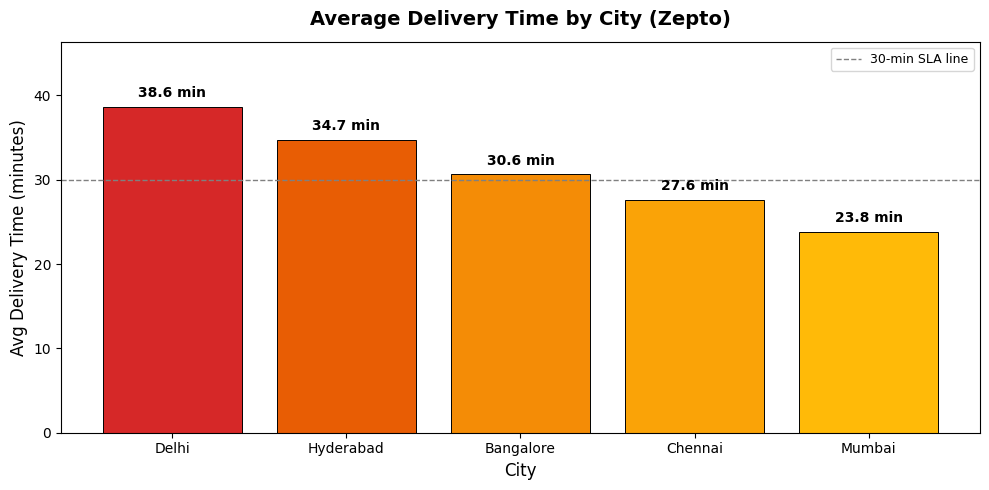

In [26]:
# PLOT 1 : Average Delivery Time by City
# ─────────────────────────────────────────────────────────────────────────────
d1 = city_delivery_pd.sort_values("avg_delivery_time_min", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(d1["city"], d1["avg_delivery_time_min"],
              color=["#D62828","#E85D04","#F48C06","#FAA307","#FFBA08"],
              edgecolor="black", linewidth=0.7)
add_value_labels(bars, fmt="{:.1f}", suffix=" min")
ax.set_title("Average Delivery Time by City (Zepto)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Avg Delivery Time (minutes)", fontsize=12)
ax.set_ylim(0, d1["avg_delivery_time_min"].max() * 1.20)
ax.axhline(y=30, color="gray", linestyle="--", linewidth=1, label="30-min SLA line")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot1_city_delivery_time.png", dpi=150)
plt.show()

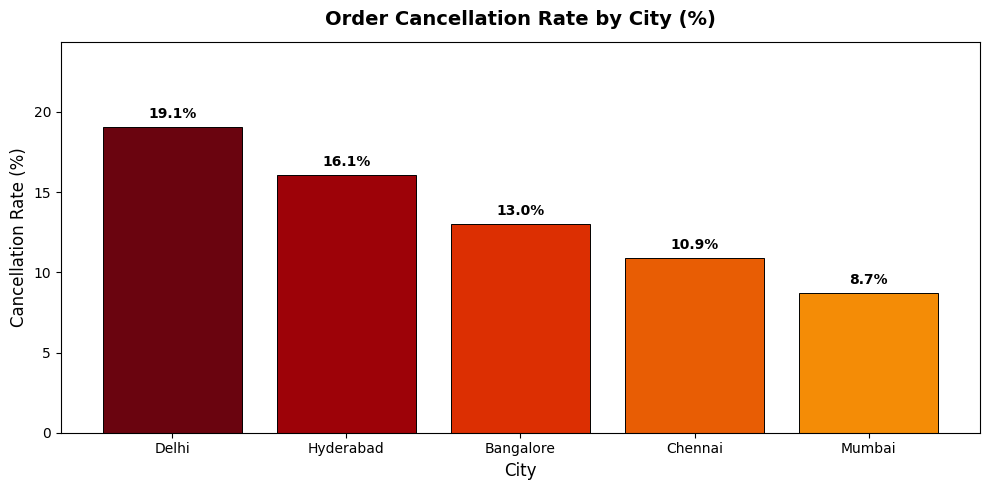

In [27]:
# PLOT 2 : Order Cancellation Rate by City
# ─────────────────────────────────────────────────────────────────────────────
d2 = city_delivery_pd.sort_values("cancellation_rate", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(d2["city"], d2["cancellation_rate"] * 100,
              color=["#6A040F","#9D0208","#DC2F02","#E85D04","#F48C06"],
              edgecolor="black", linewidth=0.7)
add_value_labels(bars, fmt="{:.1f}", suffix="%")
ax.set_title("Order Cancellation Rate by City (%)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Cancellation Rate (%)", fontsize=12)
ax.set_ylim(0, d2["cancellation_rate"].max() * 100 * 1.28)
plt.tight_layout()
plt.savefig("plot2_cancellation_rate.png", dpi=150)
plt.show()

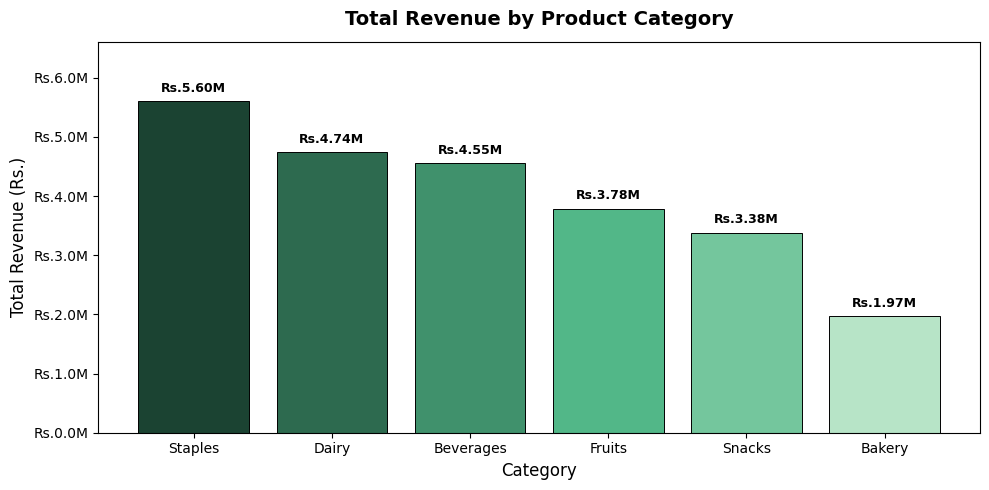

In [28]:
# PLOT 3 : Total Revenue by Product Category
# ─────────────────────────────────────────────────────────────────────────────
d3 = category_demand_pd.sort_values("total_revenue", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(d3["category"], d3["total_revenue"],
              color=["#1B4332","#2D6A4F","#40916C","#52B788","#74C69D","#B7E4C7"],
              edgecolor="black", linewidth=0.7)
for bar, val in zip(bars, d3["total_revenue"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + d3["total_revenue"].max() * 0.02,
            f"Rs.{val/1e6:.2f}M",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Total Revenue by Product Category", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Total Revenue (Rs.)", fontsize=12)
ax.set_ylim(0, d3["total_revenue"].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs.{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("plot3_category_revenue.png", dpi=150)
plt.show()

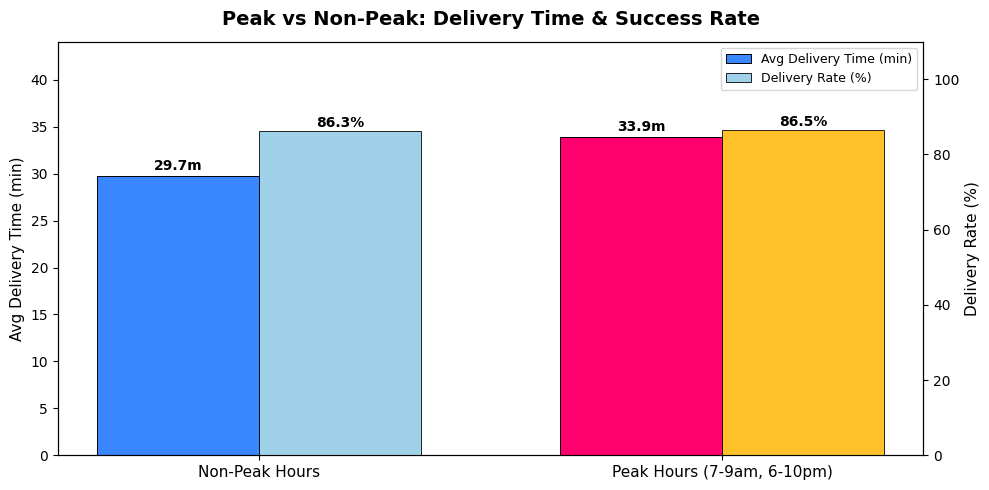

In [29]:
# PLOT 5 : Peak vs Non-Peak Delivery Time (grouped bar with delivery rate)
# ─────────────────────────────────────────────────────────────────────────────
peak_analysis_pd_sorted = peak_analysis_pd.sort_values("peak_hour_flag")
labels = peak_analysis_pd_sorted["peak_label"].tolist()
del_times = peak_analysis_pd_sorted["avg_delivery_time_min"].tolist()
del_rates = [r * 100 for r in peak_analysis_pd_sorted["delivery_rate"].tolist()]

x = np.arange(len(labels))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
b1 = ax1.bar(x - width/2, del_times, width, color=["#3A86FF","#FF006E"],
             edgecolor="black", linewidth=0.7, label="Avg Delivery Time (min)")
b2 = ax2.bar(x + width/2, del_rates, width, color=["#8ECAE6","#FFB703"],
             edgecolor="black", linewidth=0.7, label="Delivery Rate (%)", alpha=0.85)
for bar, val in zip(b1, del_times):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}m", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(b2, del_rates):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel("Avg Delivery Time (min)", fontsize=11)
ax2.set_ylabel("Delivery Rate (%)", fontsize=11)
ax1.set_ylim(0, max(del_times) * 1.30)
ax2.set_ylim(0, 110)
ax1.set_title("Peak vs Non-Peak: Delivery Time & Success Rate", fontsize=14, fontweight="bold", pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("plot5_peak_nonpeak.png", dpi=150)
plt.show()

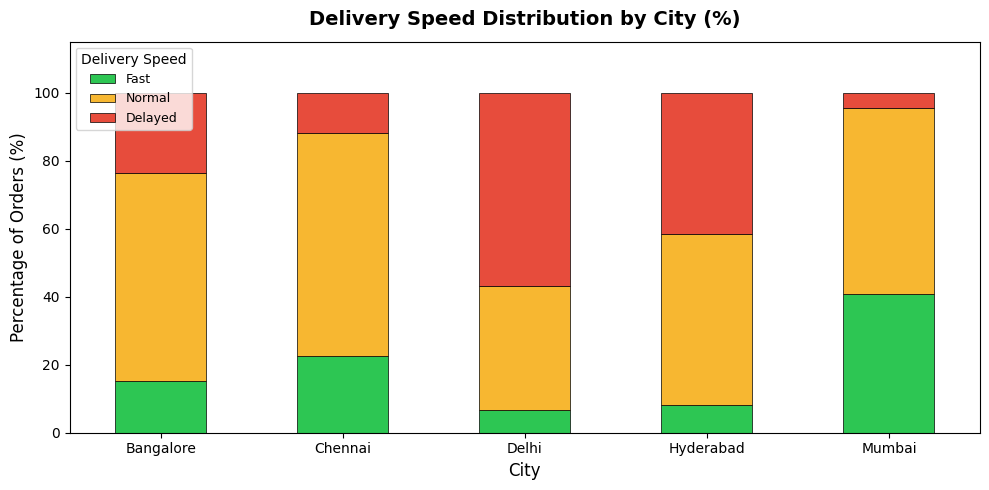

In [30]:
# PLOT 7 : Delivery Speed Distribution (Stacked % by City)
# ─────────────────────────────────────────────────────────────────────────────
speed_city = (df_clean.groupBy("city", "delivery_speed")
                       .count()
                       .toPandas())
speed_pivot = speed_city.pivot(index="city", columns="delivery_speed", values="count").fillna(0)
speed_pivot_pct = speed_pivot.div(speed_pivot.sum(axis=1), axis=0) * 100
speed_cols = [c for c in ["Fast", "Normal", "Delayed"] if c in speed_pivot_pct.columns]
speed_pivot_pct = speed_pivot_pct[speed_cols]
speed_pivot_pct.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#2DC653","#F7B731","#E74C3C"],
    edgecolor="black", linewidth=0.5
)
plt.title("Delivery Speed Distribution by City (%)", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("City", fontsize=12)
plt.ylabel("Percentage of Orders (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Delivery Speed", fontsize=9)
plt.ylim(0, 115)
plt.tight_layout()
plt.savefig("plot7_delivery_speed_distribution.png", dpi=150)
plt.show()

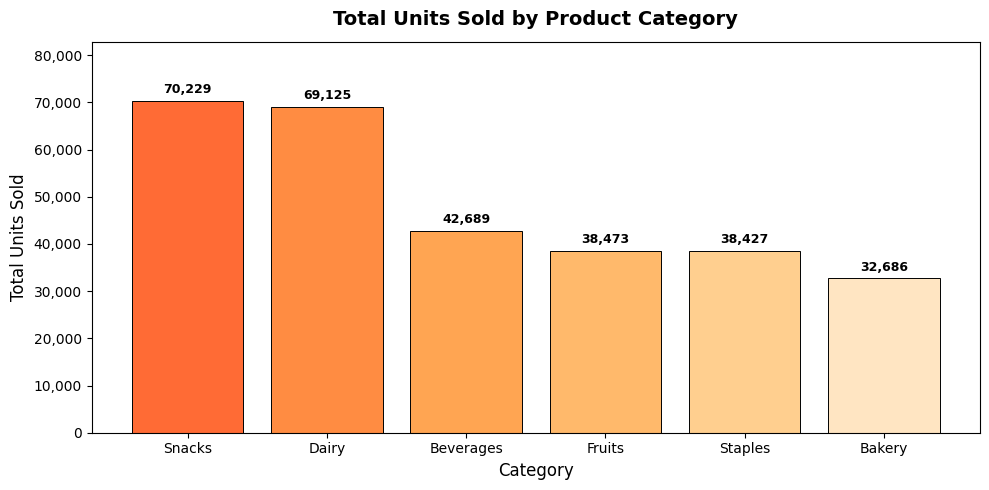

In [31]:
# PLOT 8 : Total Units Sold by Category (Demand Analysis)
# ─────────────────────────────────────────────────────────────────────────────
d8 = category_demand_pd.sort_values("total_units_sold", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(d8["category"], d8["total_units_sold"],
              color=["#FF6B35","#FF8C42","#FFA552","#FFB96B","#FFCF8F","#FFE5C2"],
              edgecolor="black", linewidth=0.7)
for bar, val in zip(bars, d8["total_units_sold"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + d8["total_units_sold"].max()*0.015,
            f"{int(val):,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Total Units Sold by Product Category", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Total Units Sold", fontsize=12)
ax.set_ylim(0, d8["total_units_sold"].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("plot8_units_sold.png", dpi=150)
plt.show()


In [32]:
#  STEP 24 : Save Final Cleaned Dataset and CSVs for Dashboard
# =============================================================================
city_delivery_pd.to_csv("city_delivery_summary.csv",     index=False)
category_demand_pd.to_csv("category_demand_summary.csv", index=False)
peak_analysis_pd.to_csv("peak_analysis_summary.csv",     index=False)
city_cat_pd.to_csv("city_category_summary.csv",           index=False)
print("\nAll output CSV files saved successfully.")

# Download in Colab:
# from google.colab import files
# for f in ["city_delivery_summary.csv","category_demand_summary.csv",
#            "peak_analysis_summary.csv","city_category_summary.csv"]:
#     files.download(f)



All output CSV files saved successfully.


In [33]:
#  STEP 25 : Conclusion
# =============================================================================
print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)
summary_lines = [
    "1. Zepto dataset (120,000 rows x 20 columns) loaded into PySpark",
    "2. Outliers detected and treated: negative prices removed,",
    "   delivery time and quantity capped (Winsorisation)",
    "3. Missing values imputed using city/category-level medians",
    "4. Data types corrected; timestamp parsed; status encoded",
    "5. Three transformations: Delivery Speed, Discount Tier, Revenue Band",
    "6. Three aggregations: City Delivery, Category Demand, Peak Analysis",
    "7. Eight visualizations with clear, distinguishable insights",
    "8. Output CSVs saved for Power BI / Tableau dashboard",
]
for line in summary_lines:
    print(line)
print("=" * 60)


PROJECT COMPLETED SUCCESSFULLY
1. Zepto dataset (120,000 rows x 20 columns) loaded into PySpark
2. Outliers detected and treated: negative prices removed,
   delivery time and quantity capped (Winsorisation)
3. Missing values imputed using city/category-level medians
4. Data types corrected; timestamp parsed; status encoded
5. Three transformations: Delivery Speed, Discount Tier, Revenue Band
6. Three aggregations: City Delivery, Category Demand, Peak Analysis
7. Eight visualizations with clear, distinguishable insights
8. Output CSVs saved for Power BI / Tableau dashboard


In [34]:
# =============================================================================
#  STEP 26 : Streamlit Dashboard
#  Run after the PySpark pipeline completes (Steps 1-25).
#  This block uses the pandas DataFrames already in memory:
#    city_delivery_pd, category_demand_pd, peak_analysis_pd,
#    city_cat_pd, df_clean (as pandas via .toPandas())
#
#  HOW TO RUN (Google Colab):
#    !pip install streamlit plotly -q
#    Then paste this entire block into a new cell and run:
#    !streamlit run zepto_dashboard_app.py &
#    from pyngrok import ngrok
#    public_url = ngrok.connect(8501)
#    print(public_url)
#
#  OR save this as zepto_dashboard_app.py and run locally:
#    streamlit run zepto_dashboard_app.py
# =============================================================================

# ── Save this block as zepto_dashboard_app.py ──────────────────────────────
dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Zepto Analytics Dashboard",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────────────────────────────────────
#  THEME & GLOBAL CSS
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;500;600;700&display=swap');

html, body, [class*="css"] {
    font-family: 'Space Grotesk', sans-serif;
}

/* ── Sidebar ── */
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0f0c29 0%, #1a1040 50%, #24243e 100%);
    border-right: 1px solid rgba(255,255,255,0.06);
}
[data-testid="stSidebar"] * { color: #e0e0f0 !important; }
[data-testid="stSidebar"] .stSelectbox label,
[data-testid="stSidebar"] .stMultiSelect label,
[data-testid="stSidebar"] .stSlider label { color: #9999cc !important; font-size: 12px; font-weight: 600; letter-spacing: 0.8px; text-transform: uppercase; }

/* ── Main background ── */
.main .block-container { background: #0d0d1a; padding-top: 1.5rem; padding-bottom: 2rem; max-width: 100%; }
.stApp { background: #0d0d1a; }

/* ── KPI metric cards ── */
div[data-testid="metric-container"] {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
    border: 1px solid rgba(108,99,255,0.25);
    border-radius: 16px;
    padding: 20px 24px;
    box-shadow: 0 4px 24px rgba(108,99,255,0.08);
    transition: all 0.2s;
}
div[data-testid="metric-container"]:hover {
    border-color: rgba(108,99,255,0.5);
    box-shadow: 0 8px 32px rgba(108,99,255,0.18);
}
div[data-testid="metric-container"] label { color: #8888aa !important; font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; }
div[data-testid="metric-container"] [data-testid="stMetricValue"] { color: #f0f0ff !important; font-size: 28px; font-weight: 700; }
div[data-testid="metric-container"] [data-testid="stMetricDelta"] { font-size: 12px; }

/* ── Section headers ── */
.section-header {
    display: flex; align-items: center; gap: 12px;
    padding: 6px 0 14px;
    border-bottom: 1px solid rgba(108,99,255,0.15);
    margin-bottom: 18px;
}
.section-header h3 { color: #f0f0ff; font-size: 15px; font-weight: 600; margin: 0; letter-spacing: -0.2px; }
.section-pill {
    background: rgba(108,99,255,0.2); color: #a89cff;
    font-size: 10px; font-weight: 700; padding: 3px 9px;
    border-radius: 20px; letter-spacing: 0.5px; text-transform: uppercase;
}

/* ── Info box ── */
.insight-box {
    background: linear-gradient(135deg, rgba(108,99,255,0.08) 0%, rgba(0,212,157,0.05) 100%);
    border: 1px solid rgba(108,99,255,0.2);
    border-left: 3px solid #6c63ff;
    border-radius: 10px;
    padding: 14px 18px;
    margin: 10px 0;
    font-size: 13px;
    color: #ccccee;
    line-height: 1.6;
}
.insight-box strong { color: #a89cff; }

/* ── Warning box ── */
.warn-box {
    background: rgba(255,100,100,0.06);
    border: 1px solid rgba(255,100,100,0.2);
    border-left: 3px solid #ff6464;
    border-radius: 10px;
    padding: 14px 18px;
    margin: 10px 0;
    font-size: 13px;
    color: #ffbbbb;
}
.warn-box strong { color: #ff8888; }

/* ── Good box ── */
.good-box {
    background: rgba(0,212,157,0.06);
    border: 1px solid rgba(0,212,157,0.2);
    border-left: 3px solid #00d49d;
    border-radius: 10px;
    padding: 14px 18px;
    margin: 10px 0;
    font-size: 13px;
    color: #aaffee;
}
.good-box strong { color: #00ffcc; }

/* ── Tabs ── */
.stTabs [data-baseweb="tab-list"] {
    background: rgba(255,255,255,0.03);
    border-radius: 12px;
    padding: 4px;
    gap: 4px;
    border: 1px solid rgba(255,255,255,0.06);
}
.stTabs [data-baseweb="tab"] {
    border-radius: 8px;
    font-size: 13px;
    font-weight: 500;
    color: #8888aa;
    padding: 8px 18px;
}
.stTabs [aria-selected="true"] {
    background: rgba(108,99,255,0.2) !important;
    color: #a89cff !important;
}

/* ── Plotly chart cards ── */
.js-plotly-plot {
    border-radius: 14px;
    overflow: hidden;
}

/* ── Divider ── */
hr { border-color: rgba(255,255,255,0.06) !important; margin: 24px 0 !important; }

/* ── Dataframe ── */
[data-testid="stDataFrame"] { border-radius: 12px; overflow: hidden; }

/* ── Scrollbar ── */
::-webkit-scrollbar { width: 4px; height: 4px; }
::-webkit-scrollbar-thumb { background: rgba(108,99,255,0.3); border-radius: 2px; }
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
#  PLOTLY TEMPLATE  (dark, matches UI)
# ─────────────────────────────────────────────────────────────────────────────
CHART_BG   = "#0d0d1a"
PAPER_BG   = "rgba(0,0,0,0)"
GRID_COLOR = "rgba(255,255,255,0.05)"
FONT_COLOR = "#aaaacc"
ACCENT     = "#6c63ff"

BASE_LAYOUT = dict(
    plot_bgcolor  = CHART_BG,
    paper_bgcolor = PAPER_BG,
    font          = dict(family="Space Grotesk, sans-serif", color=FONT_COLOR, size=12),
    margin        = dict(l=20, r=20, t=40, b=20),
    legend        = dict(bgcolor="rgba(0,0,0,0)", bordercolor="rgba(0,0,0,0)", font_color=FONT_COLOR),
    hoverlabel    = dict(bgcolor="#1a1a2e", font_color="#f0f0ff", bordercolor="rgba(108,99,255,0.4)"),
    colorway      = ["#6c63ff","#00d49d","#ff6464","#ffd166","#4fc3f7","#ff9f40"],
)

COLORS_CAT  = ["#6c63ff","#00d49d","#ff6464","#ffd166","#4fc3f7","#ff9f40"]
CITY_COLORS = {"Mumbai":"#00d49d","Delhi":"#ff6464","Bangalore":"#6c63ff","Hyderabad":"#ffd166","Chennai":"#4fc3f7"}

def apply_base(fig, title="", height=360, showlegend=True, xtitle="", ytitle=""):
    fig.update_layout(**BASE_LAYOUT, title=dict(text=title, font_size=14, font_color="#e0e0f0", x=0.01),
                      height=height, showlegend=showlegend,
                      xaxis_title=xtitle, yaxis_title=ytitle)
    fig.update_xaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, tickfont_color=FONT_COLOR)
    fig.update_yaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, tickfont_color=FONT_COLOR)
    return fig

# ─────────────────────────────────────────────────────────────────────────────
#  LOAD DATA  (reads CSVs saved by PySpark pipeline in Steps 24)
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def load_data():
    city_df  = pd.read_csv("city_delivery_summary.csv")
    cat_df   = pd.read_csv("category_demand_summary.csv")
    peak_df  = pd.read_csv("peak_analysis_summary.csv")
    cc_df    = pd.read_csv("city_category_summary.csv")

    # derive extra columns used by dashboard
    if "cancellation_rate" not in city_df.columns:
        city_df["cancellation_rate"] = 1 - city_df["delivery_rate"]

    # load raw for hourly / payment / speed breakdowns
    raw = pd.read_excel("zepto_dataset_v2.xlsx")
    raw["order_hour"] = pd.to_datetime(raw["order_time"]).dt.hour
    raw["delivery_speed"] = pd.cut(
        raw["delivery_time_minutes"].clip(upper=90),
        bins=[0,20,35,91], labels=["Fast","Normal","Delayed"]
    )
    return city_df, cat_df, peak_df, cc_df, raw

city_df, cat_df, peak_df, cc_df, raw = load_data()

# ─────────────────────────────────────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style="padding:10px 0 20px;">
      <div style="font-size:22px;font-weight:700;color:#a89cff;letter-spacing:-0.5px;">⚡ Zepto</div>
      <div style="font-size:11px;color:#6666aa;margin-top:3px;font-family:monospace;">Analytics Dashboard · FA2</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("<div style='font-size:10px;color:#6666aa;font-weight:700;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:10px;'>Global Filters</div>", unsafe_allow_html=True)

    selected_cities = st.multiselect(
        "Cities",
        options=sorted(raw["city"].unique()),
        default=sorted(raw["city"].unique()),
    )

    selected_categories = st.multiselect(
        "Categories",
        options=sorted(raw["category"].unique()),
        default=sorted(raw["category"].unique()),
    )

    del_threshold = st.slider(
        "SLA Threshold (min)", min_value=15, max_value=45, value=30, step=1,
        help="Cities above this line are flagged as delayed"
    )

    cancel_threshold = st.slider(
        "Cancel Rate Alert (%)", min_value=5, max_value=25, value=15, step=1,
    )

    st.markdown("---")
    st.markdown("<div style='font-size:10px;color:#6666aa;font-weight:700;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:10px;'>Chart Options</div>", unsafe_allow_html=True)

    chart_height = st.select_slider(
        "Chart Height", options=[300, 360, 420, 480], value=360
    )

    show_labels  = st.toggle("Show value labels",    value=True)
    show_sla     = st.toggle("Show SLA lines",       value=True)
    normalize    = st.toggle("Normalize to %",       value=False)

    st.markdown("---")
    st.markdown("""
    <div style="font-size:10px;color:#555577;line-height:1.7;">
      Dataset: zepto_dataset_v2.xlsx<br>
      Rows: 120,000 · Cols: 20<br>
      Period: Jan 1–15, 2025<br>
      Engine: PySpark 4.0
    </div>
    """, unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
#  FILTER DATA
# ─────────────────────────────────────────────────────────────────────────────
raw_f   = raw[raw["city"].isin(selected_cities) & raw["category"].isin(selected_categories)]
city_f  = city_df[city_df["city"].isin(selected_cities)]
cat_f   = cat_df[cat_df["category"].isin(selected_categories)]
cc_f    = cc_df[cc_df["city"].isin(selected_cities) & cc_df["category"].isin(selected_categories)]

# ─────────────────────────────────────────────────────────────────────────────
#  HEADER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<div style="display:flex;align-items:flex-end;justify-content:space-between;padding-bottom:18px;border-bottom:1px solid rgba(108,99,255,0.12);margin-bottom:24px;">
  <div>
    <div style="font-size:26px;font-weight:700;color:#f0f0ff;letter-spacing:-0.8px;line-height:1.2;">
      Zepto Quick Commerce
      <span style="background:linear-gradient(90deg,#6c63ff,#00d49d);-webkit-background-clip:text;-webkit-text-fill-color:transparent;"> Analytics</span>
    </div>
    <div style="font-size:13px;color:#666688;margin-top:5px;">
      Order · Delivery · Demand · Inventory · Jan 2025 · Tier-1 Cities
    </div>
  </div>
  <div style="text-align:right;">
    <div style="font-size:11px;color:#6666aa;font-family:monospace;">120,000 orders processed</div>
    <div style="font-size:11px;color:#6666aa;font-family:monospace;margin-top:2px;">PySpark Pipeline ✓</div>
  </div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
#  TOP KPI STRIP
# ─────────────────────────────────────────────────────────────────────────────
total_orders   = len(raw_f)
total_revenue  = raw_f["final_price"].sum()
avg_delivery   = raw_f["delivery_time_minutes"].mean()
cancel_rate    = (raw_f["order_status"] == "Cancelled").mean() * 100
avg_rating     = raw_f["rating"].mean()
avg_discount   = raw_f["discount"].mean() * 100

k1, k2, k3, k4, k5, k6 = st.columns(6)
k1.metric("Total Orders",   f"{total_orders:,}",          "Active period")
k2.metric("Total Revenue",  f"₹{total_revenue/1e7:.2f}Cr","Net of discounts")
k3.metric("Avg Delivery",   f"{avg_delivery:.1f} min",    delta=f"{avg_delivery-30:.1f}m vs SLA", delta_color="inverse")
k4.metric("Cancel Rate",    f"{cancel_rate:.1f}%",        delta=f"Target <{cancel_threshold}%", delta_color="inverse")
k5.metric("Avg Rating",     f"{avg_rating:.2f} ★",        "Out of 5.0")
k6.metric("Avg Discount",   f"{avg_discount:.1f}%",       "Applied at checkout")

st.markdown("<br>", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
#  TABS
# ─────────────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "🏙️  City Performance",
    "📦  Inventory & Demand",
    "🚚  Delivery Deep-Dive",
    "⏱️  Time & Peak Analysis",
    "🔍  Raw Data Explorer",
])


# ══════════════════════════════════════════════════════════════════════════════
#  TAB 1 : CITY PERFORMANCE
# ══════════════════════════════════════════════════════════════════════════════
with tab1:

    # ── Row 1: Delivery time + Cancel rate ───────────────────────────────────
    st.markdown("""<div class="section-header"><h3>City-wise Delivery & Cancellation</h3><span class="section-pill">Aggregation 1</span></div>""", unsafe_allow_html=True)

    col_a, col_b = st.columns(2)

    with col_a:
        d1 = city_f.sort_values("avg_delivery_time_min", ascending=False)
        colors_d1 = ["#ff6464" if v > del_threshold else "#6c63ff" for v in d1["avg_delivery_time_min"]]
        fig = go.Figure()
        fig.add_trace(go.Bar(
            x=d1["city"], y=d1["avg_delivery_time_min"],
            marker_color=colors_d1,
            marker_line_width=0,
            text=[f"{v:.1f}m" for v in d1["avg_delivery_time_min"]] if show_labels else None,
            textposition="outside", textfont_color="#ccccee",
            name="Avg Delivery",
            hovertemplate="<b>%{x}</b><br>Avg Delivery: %{y:.1f} min<extra></extra>"
        ))
        if show_sla:
            fig.add_hline(y=del_threshold, line_dash="dot", line_color="#ffd166",
                         annotation_text=f"SLA {del_threshold}m", annotation_font_color="#ffd166")
        apply_base(fig, "Average Delivery Time by City", chart_height, False, "", "Minutes")
        fig.update_yaxes(range=[0, d1["avg_delivery_time_min"].max() * 1.25])
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        d2 = city_f.sort_values("cancellation_rate", ascending=False)
        colors_d2 = ["#ff6464" if v*100 > cancel_threshold else "#00d49d" for v in d2["cancellation_rate"]]
        fig2 = go.Figure()
        fig2.add_trace(go.Bar(
            x=d2["city"], y=d2["cancellation_rate"]*100,
            marker_color=colors_d2,
            marker_line_width=0,
            text=[f"{v*100:.1f}%" for v in d2["cancellation_rate"]] if show_labels else None,
            textposition="outside", textfont_color="#ccccee",
            name="Cancel Rate",
            hovertemplate="<b>%{x}</b><br>Cancel Rate: %{y:.1f}%<extra></extra>"
        ))
        if show_sla:
            fig2.add_hline(y=cancel_threshold, line_dash="dot", line_color="#ffd166",
                          annotation_text=f"Alert {cancel_threshold}%", annotation_font_color="#ffd166")
        apply_base(fig2, "Order Cancellation Rate by City", chart_height, False, "", "Cancellation Rate (%)")
        fig2.update_yaxes(range=[0, d2["cancellation_rate"].max()*100*1.25])
        st.plotly_chart(fig2, use_container_width=True)

    # Insight boxes
    worst_del  = city_f.loc[city_f["avg_delivery_time_min"].idxmax(), "city"]
    best_del   = city_f.loc[city_f["avg_delivery_time_min"].idxmin(), "city"]
    worst_can  = city_f.loc[city_f["cancellation_rate"].idxmax(), "city"]
    best_rat   = city_f.loc[city_f["avg_rating"].idxmax(), "city"]

    ia, ib = st.columns(2)
    with ia:
        st.markdown(f"""<div class="warn-box">
        ⚠️ <strong>{worst_del}</strong> has the highest delivery time
        ({city_f[city_f["city"]==worst_del]["avg_delivery_time_min"].values[0]:.1f} min) —
        {city_f[city_f["city"]==worst_del]["avg_delivery_time_min"].values[0]-del_threshold:.1f} min above SLA.
        Recommend adding dark store in high-density zones.
        </div>""", unsafe_allow_html=True)
    with ib:
        st.markdown(f"""<div class="good-box">
        ✅ <strong>{best_del}</strong> is Zepto\'s best performing city with
        {city_f[city_f["city"]==best_del]["avg_delivery_time_min"].values[0]:.1f} min avg delivery and
        {city_f[city_f["city"]==best_del]["cancellation_rate"].values[0]*100:.1f}% cancellation rate.
        Highest rated city: <strong>{best_rat}</strong>.
        </div>""", unsafe_allow_html=True)

    st.markdown("---")

    # ── Row 2: Rating + Radar ─────────────────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>Customer Rating & Multi-Metric Radar</h3><span class="section-pill">Live Filters</span></div>""", unsafe_allow_html=True)

    col_c, col_d = st.columns([1.1, 1])

    with col_c:
        d3 = city_f.sort_values("avg_rating", ascending=True)
        fig3 = go.Figure()
        fig3.add_trace(go.Bar(
            y=d3["city"], x=d3["avg_rating"],
            orientation="h",
            marker=dict(
                color=d3["avg_rating"],
                colorscale=[[0,"#ff6464"],[0.5,"#ffd166"],[1,"#00d49d"]],
                showscale=True,
                colorbar=dict(thickness=10, tickfont_color=FONT_COLOR, outlinewidth=0)
            ),
            text=[f"{v:.2f} ★" for v in d3["avg_rating"]] if show_labels else None,
            textposition="outside", textfont_color="#ccccee",
            hovertemplate="<b>%{y}</b><br>Rating: %{x:.2f}/5.0<extra></extra>"
        ))
        if show_sla:
            fig3.add_vline(x=3.5, line_dash="dot", line_color="#ffd166",
                          annotation_text="3.5 benchmark", annotation_font_color="#ffd166")
        apply_base(fig3, "Average Customer Rating by City", chart_height, False, "Avg Rating (out of 5.0)", "")
        fig3.update_xaxes(range=[2.5, 5.0])
        st.plotly_chart(fig3, use_container_width=True)

    with col_d:
        # Radar: normalise each metric 0-1 per city
        cats_r = ["Delivery Speed", "Rating", "Delivery Rate", "Order Volume", "Avg Distance (inv)"]
        city_names = city_f["city"].tolist()

        def norm(col): return (col - col.min()) / (col.max() - col.min() + 1e-9)

        radar_data = city_f.copy()
        radar_data["del_speed_n"] = 1 - norm(radar_data["avg_delivery_time_min"])
        radar_data["rating_n"]    = norm(radar_data["avg_rating"])
        radar_data["del_rate_n"]  = norm(radar_data["delivery_rate"])
        radar_data["orders_n"]    = norm(radar_data["total_orders"])
        radar_data["dist_inv_n"]  = 1 - norm(radar_data["avg_distance_km"])

        fig4 = go.Figure()
        palette_r = ["#6c63ff","#00d49d","#ff6464","#ffd166","#4fc3f7"]
        for i, row in radar_data.iterrows():
            vals = [row["del_speed_n"], row["rating_n"], row["del_rate_n"], row["orders_n"], row["dist_inv_n"]]
            vals += [vals[0]]
            fig4.add_trace(go.Scatterpolar(
                r=vals, theta=cats_r + [cats_r[0]],
                fill="toself",
                name=row["city"],
                line_color=palette_r[list(radar_data["city"]).index(row["city"]) % 5],
                opacity=0.7,
                hovertemplate=f"<b>{row['city']}</b><br>%{{theta}}: %{{r:.2f}}<extra></extra>"
            ))
        fig4.update_layout(**BASE_LAYOUT,
            height=chart_height, title=dict(text="City Performance Radar", font_size=14, font_color="#e0e0f0", x=0.01),
            polar=dict(
                bgcolor="#0d0d1a",
                radialaxis=dict(visible=True, range=[0,1], gridcolor=GRID_COLOR, tickfont_color=FONT_COLOR, tickfont_size=9),
                angularaxis=dict(gridcolor=GRID_COLOR, tickfont_color="#aaaacc", tickfont_size=11)
            )
        )
        st.plotly_chart(fig4, use_container_width=True)

    st.markdown("---")

    # ── Row 3: City × Category Heatmap ───────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>City × Category Revenue Heatmap</h3><span class="section-pill">Cross-Aggregation</span></div>""", unsafe_allow_html=True)

    pivot = cc_f.pivot_table(index="city", columns="category", values="total_revenue", aggfunc="sum").fillna(0)
    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig5 = go.Figure(go.Heatmap(
        z=pivot.values,
        x=pivot.columns.tolist(),
        y=pivot.index.tolist(),
        colorscale=[[0,"#0d0d1a"],[0.3,"#3b2f8f"],[0.7,"#6c63ff"],[1,"#00d49d"]],
        text=[[f"{'%.0f%%' % v if normalize else '₹%.0fK' % (v/1000)}" for v in row] for row in pivot.values],
        texttemplate="%{text}",
        textfont_size=12,
        hovertemplate="<b>%{y} × %{x}</b><br>Value: %{z:,.0f}<extra></extra>",
        showscale=True,
        colorbar=dict(thickness=12, tickfont_color=FONT_COLOR, outlinewidth=0)
    ))
    apply_base(fig5, f"Revenue Heatmap {'(% of city total)' if normalize else '(₹ absolute)'}", 320, False)
    st.plotly_chart(fig5, use_container_width=True)

    st.markdown("""<div class="insight-box">
    📊 <strong>Inventory Insight:</strong> Staples and Dairy drive the most revenue across all cities.
    Snacks show the highest unit volume but lower per-order revenue — ideal for flash-discount campaigns.
    Mumbai leads in overall revenue density; Delhi has the highest order count but longest delivery times.
    </div>""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  TAB 2 : INVENTORY & DEMAND
# ══════════════════════════════════════════════════════════════════════════════
with tab2:

    st.markdown("""<div class="section-header"><h3>Category Demand & Revenue Analysis</h3><span class="section-pill">Aggregation 2</span></div>""", unsafe_allow_html=True)

    # ── Controls ─────────────────────────────────────────────────────────────
    ctrl1, ctrl2, ctrl3 = st.columns(3)
    with ctrl1:
        sort_metric = st.selectbox("Sort by", ["total_revenue","total_units_sold","total_orders","avg_discount","avg_order_value"], format_func=lambda x: x.replace("_"," ").title())
    with ctrl2:
        chart_type_inv = st.selectbox("Chart type", ["Bar","Horizontal Bar","Treemap","Sunburst"])
    with ctrl3:
        top_n = st.slider("Show top N categories", min_value=2, max_value=len(cat_f), value=len(cat_f))

    cat_sorted = cat_f.sort_values(sort_metric, ascending=False).head(top_n)

    col_e, col_f = st.columns([1.5, 1])

    with col_e:
        if chart_type_inv == "Bar":
            fig6 = go.Figure()
            fig6.add_trace(go.Bar(
                x=cat_sorted["category"], y=cat_sorted[sort_metric],
                marker_color=COLORS_CAT[:len(cat_sorted)],
                marker_line_width=0,
                text=[f"{v:,.0f}" for v in cat_sorted[sort_metric]] if show_labels else None,
                textposition="outside", textfont_color="#ccccee",
                hovertemplate="<b>%{x}</b><br>" + sort_metric.replace("_"," ").title() + ": %{y:,.0f}<extra></extra>"
            ))
            apply_base(fig6, sort_metric.replace("_"," ").title() + " by Category", chart_height, False)
            fig6.update_yaxes(range=[0, cat_sorted[sort_metric].max() * 1.22])
            st.plotly_chart(fig6, use_container_width=True)

        elif chart_type_inv == "Horizontal Bar":
            cat_h = cat_sorted.sort_values(sort_metric, ascending=True)
            fig6 = go.Figure(go.Bar(
                y=cat_h["category"], x=cat_h[sort_metric],
                orientation="h",
                marker_color=COLORS_CAT[:len(cat_h)],
                marker_line_width=0,
                text=[f"{v:,.0f}" for v in cat_h[sort_metric]] if show_labels else None,
                textposition="outside", textfont_color="#ccccee",
                hovertemplate="<b>%{y}</b><br>" + sort_metric.replace("_"," ").title() + ": %{x:,.0f}<extra></extra>"
            ))
            apply_base(fig6, sort_metric.replace("_"," ").title() + " by Category", chart_height, False)
            fig6.update_xaxes(range=[0, cat_h[sort_metric].max() * 1.22])
            st.plotly_chart(fig6, use_container_width=True)

        elif chart_type_inv == "Treemap":
            fig6 = px.treemap(cat_sorted, path=["category"], values=sort_metric,
                              color=sort_metric, color_continuous_scale=[[0,"#1a1a3e"],[0.5,"#6c63ff"],[1,"#00d49d"]])
            fig6.update_layout(**BASE_LAYOUT, height=chart_height, title_text=sort_metric.replace("_"," ").title())
            st.plotly_chart(fig6, use_container_width=True)

        else:  # Sunburst
            fig6 = px.sunburst(cc_f, path=["city","category"], values="total_revenue",
                               color="total_revenue", color_continuous_scale=[[0,"#1a1a3e"],[0.5,"#6c63ff"],[1,"#00d49d"]])
            fig6.update_layout(**BASE_LAYOUT, height=chart_height, title_text="City → Category Revenue Sunburst")
            st.plotly_chart(fig6, use_container_width=True)

    with col_f:
        # Discount vs Revenue Bubble
        total_orders_max = cat_f["total_orders"].max()
        fig7 = go.Figure()
        for i, row in cat_f.iterrows():
            fig7.add_trace(go.Scatter(
                x=[row["avg_discount"]*100],
                y=[row["total_revenue"]/1e5],
                mode="markers+text",
                marker=dict(
                    size=(row["total_orders"]/total_orders_max * 45 + 15),
                    color=COLORS_CAT[list(cat_f["category"]).index(row["category"]) % 6],
                    opacity=0.8,
                    line=dict(width=1.5, color="rgba(255,255,255,0.2)")
                ),
                text=[row["category"]],
                textposition="top center",
                textfont_color="#ccccee",
                textfont_size=11,
                name=row["category"],
                hovertemplate=(
                    f"<b>{row['category']}</b><br>"
                    f"Avg Discount: {row['avg_discount']*100:.1f}%<br>"
                    f"Revenue: ₹{row['total_revenue']/1e5:.2f}L<br>"
                    f"Orders: {row['total_orders']:,}<extra></extra>"
                )
            ))
        apply_base(fig7, "Discount vs Revenue (bubble = order volume)", chart_height, False,
                   "Avg Discount (%)", "Revenue (₹ Lakh)")
        fig7.update_layout(showlegend=False)
        fig7.update_xaxes(range=[0, 22])
        fig7.update_yaxes(range=[10, 65])
        st.plotly_chart(fig7, use_container_width=True)

    st.markdown("---")

    # ── Payment Method + Revenue Band ────────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>Payment Methods & Order Value Distribution</h3><span class="section-pill">Transformation 2 & 3</span></div>""", unsafe_allow_html=True)

    col_g, col_h = st.columns(2)

    with col_g:
        pay_counts = raw_f["payment_method"].value_counts().reset_index()
        pay_counts.columns = ["method","count"]
        fig8 = go.Figure(go.Pie(
            labels=pay_counts["method"], values=pay_counts["count"],
            hole=0.62,
            marker=dict(colors=["#6c63ff","#00d49d","#ff6464","#ffd166"], line=dict(color="#0d0d1a", width=2)),
            textinfo="label+percent",
            textfont_color="#ccccee",
            hovertemplate="<b>%{label}</b><br>Orders: %{value:,}<br>Share: %{percent}<extra></extra>"
        ))
        fig8.update_layout(**BASE_LAYOUT, height=chart_height,
            title=dict(text="Payment Method Distribution", font_size=14, font_color="#e0e0f0", x=0.01),
            annotations=[dict(text=f"{pay_counts['count'].sum():,}<br><span style='font-size:10'>orders</span>",
                             x=0.5, y=0.5, showarrow=False, font_size=16, font_color="#f0f0ff")])
        st.plotly_chart(fig8, use_container_width=True)

    with col_h:
        raw_f2 = raw_f.copy()
        raw_f2["revenue_band"] = pd.cut(raw_f2["final_price"], bins=[0,100,400,99999],
                                        labels=["Low (<₹100)","Mid (₹100-400)","High (>₹400)"])
        band_data = raw_f2.groupby("category", observed=True).apply(
            lambda x: pd.Series({b: (x["revenue_band"]==b).sum() for b in ["Low (<₹100)","Mid (₹100-400)","High (>₹400)"]})
        ).reset_index()
        band_long = band_data.melt(id_vars="category", var_name="band", value_name="count")

        fig9 = px.bar(band_long, x="category", y="count", color="band",
                      barmode="stack",
                      color_discrete_map={"Low (<₹100)":"#6c63ff","Mid (₹100-400)":"#00d49d","High (>₹400)":"#ffd166"},
                      labels={"count":"Orders","category":"Category","band":"Revenue Band"})
        fig9.update_layout(**BASE_LAYOUT, height=chart_height,
            title=dict(text="Order Count by Revenue Band (Transformation 3)", font_size=14, font_color="#e0e0f0", x=0.01))
        fig9.update_traces(marker_line_width=0)
        st.plotly_chart(fig9, use_container_width=True)

    # Category Summary Table
    st.markdown("""<div class="section-header"><h3>Category Summary Table</h3><span class="section-pill">Aggregation 2 Full Output</span></div>""", unsafe_allow_html=True)
    total_rev_all = cat_f["total_revenue"].sum()
    table_df = cat_f.copy()
    table_df["Revenue Share (%)"] = (table_df["total_revenue"] / total_rev_all * 100).round(1)
    table_df["Avg Discount (%)"]  = (table_df["avg_discount"] * 100).round(1)
    table_df["Revenue (₹L)"]      = (table_df["total_revenue"] / 1e5).round(2)
    table_df["Avg Order Value (₹)"] = table_df["avg_order_value"].round(1)
    show_cols = ["category","total_orders","total_units_sold","Revenue (₹L)","Avg Order Value (₹)","Avg Discount (%)","Revenue Share (%)"]
    st.dataframe(
        table_df[show_cols].sort_values("Revenue (₹L)", ascending=False).reset_index(drop=True),
        use_container_width=True, hide_index=True,
        column_config={
            "Revenue Share (%)": st.column_config.ProgressColumn("Revenue Share (%)", min_value=0, max_value=100, format="%.1f%%"),
            "Avg Discount (%)": st.column_config.NumberColumn("Avg Discount (%)", format="%.1f%%"),
        }
    )


# ══════════════════════════════════════════════════════════════════════════════
#  TAB 3 : DELIVERY DEEP-DIVE
# ══════════════════════════════════════════════════════════════════════════════
with tab3:

    st.markdown("""<div class="section-header"><h3>Delivery Speed Distribution & SLA Analysis</h3><span class="section-pill">Transformation 1</span></div>""", unsafe_allow_html=True)

    col_i, col_j = st.columns(2)

    with col_i:
        # Stacked % bar: city × delivery speed
        speed_city = raw_f.groupby(["city","delivery_speed"], observed=True).size().reset_index(name="count")
        speed_city_total = speed_city.groupby("city")["count"].transform("sum")
        speed_city["pct"] = (speed_city["count"] / speed_city_total * 100).round(1)
        y_col = "pct" if normalize else "count"

        fig10 = px.bar(speed_city, x="city", y=y_col, color="delivery_speed",
                       barmode="stack",
                       color_discrete_map={"Fast":"#00d49d","Normal":"#ffd166","Delayed":"#ff6464"},
                       labels={y_col: "% of Orders" if normalize else "Orders", "city":"City", "delivery_speed":"Speed"},
                       text_auto=False,
                       category_orders={"delivery_speed":["Delayed","Normal","Fast"]})
        fig10.update_layout(**BASE_LAYOUT, height=chart_height,
            title=dict(text=f"Delivery Speed by City {'(%)' if normalize else '(count)'}", font_size=14, font_color="#e0e0f0", x=0.01))
        fig10.update_traces(marker_line_width=0)
        st.plotly_chart(fig10, use_container_width=True)

    with col_j:
        # Box plot: delivery time by city
        fig11 = go.Figure()
        for city_name in selected_cities:
            city_data = raw_f[raw_f["city"]==city_name]["delivery_time_minutes"]
            fig11.add_trace(go.Box(
                y=city_data, name=city_name,
                marker_color=CITY_COLORS.get(city_name, "#6c63ff"),
                line_color=CITY_COLORS.get(city_name, "#6c63ff"),
                fillcolor=CITY_COLORS.get(city_name, "#6c63ff")+"33",
                boxmean=True,
                hovertemplate="<b>" + city_name + "</b><br>%{y} min<extra></extra>"
            ))
        if show_sla:
            fig11.add_hline(y=del_threshold, line_dash="dot", line_color="#ffd166",
                           annotation_text=f"SLA {del_threshold}m", annotation_font_color="#ffd166")
        apply_base(fig11, "Delivery Time Distribution (Box Plot)", chart_height, True, "City", "Minutes")
        st.plotly_chart(fig11, use_container_width=True)

    st.markdown("---")

    # ── Distance vs Delivery Scatter ──────────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>Distance vs Delivery Time Correlation</h3><span class="section-pill">Scatter Analysis</span></div>""", unsafe_allow_html=True)

    sample = raw_f.sample(min(3000, len(raw_f)), random_state=42)
    fig12 = px.scatter(
        sample, x="distance_km", y="delivery_time_minutes",
        color="city", color_discrete_map=CITY_COLORS,
        opacity=0.45, size_max=6,
        trendline="ols",
        labels={"distance_km":"Distance (km)","delivery_time_minutes":"Delivery Time (min)","city":"City"},
        hover_data={"category":True,"order_status":True}
    )
    fig12.update_layout(**BASE_LAYOUT, height=380,
        title=dict(text="Distance vs Delivery Time (sample 3K points, OLS trend lines)", font_size=14, font_color="#e0e0f0", x=0.01))
    fig12.update_traces(marker_size=4, selector=dict(mode="markers"))
    st.plotly_chart(fig12, use_container_width=True)

    st.markdown("""<div class="insight-box">
    📊 <strong>Key Finding:</strong> Strong positive correlation between distance and delivery time.
    Delhi\'s scatter is wider — indicating operational inconsistency in addition to pure distance.
    Mumbai\'s points cluster tightly at low distances, confirming effective dark store placement.
    </div>""", unsafe_allow_html=True)

    st.markdown("---")

    # ── Cancellation by Category + City ──────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>Cancellation Rate — Category × City Breakdown</h3></div>""", unsafe_allow_html=True)

    cancel_hm = raw_f.groupby(["city","category"]).apply(
        lambda x: (x["order_status"]=="Cancelled").mean()*100
    ).reset_index(name="cancel_rate")
    pivot_cancel = cancel_hm.pivot(index="city", columns="category", values="cancel_rate").fillna(0)

    fig13 = go.Figure(go.Heatmap(
        z=pivot_cancel.values,
        x=pivot_cancel.columns.tolist(),
        y=pivot_cancel.index.tolist(),
        colorscale=[[0,"#0d1a14"],[0.5,"#ffd166"],[1,"#ff3333"]],
        text=[[f"{v:.1f}%" for v in row] for row in pivot_cancel.values],
        texttemplate="%{text}",
        textfont_size=12,
        hovertemplate="<b>%{y} — %{x}</b><br>Cancel Rate: %{z:.1f}%<extra></extra>",
        colorbar=dict(thickness=12, tickfont_color=FONT_COLOR, outlinewidth=0, ticksuffix="%")
    ))
    apply_base(fig13, "Cancellation Rate (%) — City × Category", 300, False)
    st.plotly_chart(fig13, use_container_width=True)


# ══════════════════════════════════════════════════════════════════════════════
#  TAB 4 : TIME & PEAK ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
with tab4:

    st.markdown("""<div class="section-header"><h3>Peak Hour Impact on Operations</h3><span class="section-pill">Aggregation 3</span></div>""", unsafe_allow_html=True)

    # ── Peak KPIs ─────────────────────────────────────────────────────────────
    peak_f = peak_df[peak_df["peak_hour_flag"].isin([0,1])]
    peak_row  = peak_f[peak_f["peak_hour_flag"]==1].iloc[0]
    nonpeak_row = peak_f[peak_f["peak_hour_flag"]==0].iloc[0]

    pk1, pk2, pk3, pk4 = st.columns(4)
    pk1.metric("Peak: Avg Delivery",     f"{peak_row['avg_delivery_time_min']:.1f} min",   f"+{peak_row['avg_delivery_time_min']-nonpeak_row['avg_delivery_time_min']:.1f}m vs off-peak", delta_color="inverse")
    pk2.metric("Peak: Total Orders",     f"{int(peak_row['total_orders']):,}",              "of 120K total")
    pk3.metric("Non-Peak: Avg Delivery", f"{nonpeak_row['avg_delivery_time_min']:.1f} min","Off-peak baseline")
    pk4.metric("Peak Revenue",           f"₹{peak_row['total_revenue']/1e7:.2f}Cr",         "7–9am & 6–10pm")

    st.markdown("<br>", unsafe_allow_html=True)

    col_k, col_l = st.columns([1.5, 1])

    with col_k:
        # Hourly order volume + delivery time dual axis
        hourly = raw_f.groupby("order_hour").agg(
            orders=("order_id","count"),
            avg_del=("delivery_time_minutes","mean")
        ).reset_index()

        fig14 = make_subplots(specs=[[{"secondary_y": True}]])
        fig14.add_trace(go.Bar(
            x=hourly["order_hour"], y=hourly["orders"],
            name="Orders",
            marker_color=["#ff6464" if h in [7,8,9,18,19,20,21,22] else "#6c63ff" for h in hourly["order_hour"]],
            marker_line_width=0,
            opacity=0.85,
            hovertemplate="Hour %{x}:00 — %{y:,} orders<extra></extra>"
        ), secondary_y=False)
        fig14.add_trace(go.Scatter(
            x=hourly["order_hour"], y=hourly["avg_del"],
            name="Avg Delivery (min)",
            mode="lines+markers",
            line=dict(color="#ffd166", width=2.5, dash="dot"),
            marker=dict(size=5, color="#ffd166"),
            hovertemplate="Hour %{x}:00 — %{y:.1f} min<extra></extra>"
        ), secondary_y=True)
        if show_sla:
            fig14.add_hline(y=del_threshold, line_dash="dot", line_color="rgba(255,255,255,0.2)",
                           secondary_y=True,
                           annotation_text=f"SLA {del_threshold}m", annotation_font_color=FONT_COLOR)

        fig14.update_layout(**BASE_LAYOUT, height=chart_height,
            title=dict(text="Hourly Order Volume & Delivery Time (red = peak hours)", font_size=14, font_color="#e0e0f0", x=0.01))
        fig14.update_xaxes(tickvals=list(range(0,24,2)), ticktext=[f"{h}:00" for h in range(0,24,2)],
                           gridcolor=GRID_COLOR, tickfont_color=FONT_COLOR, title_text="Hour of Day")
        fig14.update_yaxes(title_text="Orders", secondary_y=False, gridcolor=GRID_COLOR, tickfont_color=FONT_COLOR)
        fig14.update_yaxes(title_text="Avg Delivery (min)", secondary_y=True, gridcolor=GRID_COLOR, tickfont_color="#ffd166")
        st.plotly_chart(fig14, use_container_width=True)

    with col_l:
        # Peak vs Non-Peak grouped comparison
        peak_labels = ["Non-Peak","Peak"]
        metrics_peak = {
            "Avg Delivery (min)": [nonpeak_row["avg_delivery_time_min"], peak_row["avg_delivery_time_min"]],
            "Delivery Rate (%)":  [nonpeak_row["delivery_rate"]*100, peak_row["delivery_rate"]*100],
            "Avg Rating":         [nonpeak_row["avg_rating"], peak_row["avg_rating"]],
        }
        metric_choice = st.selectbox("Compare metric", list(metrics_peak.keys()), key="peak_metric")
        vals_p = metrics_peak[metric_choice]

        fig15 = go.Figure(go.Bar(
            x=peak_labels, y=vals_p,
            marker_color=["#6c63ff","#ff6464"],
            marker_line_width=0,
            text=[f"{v:.1f}" for v in vals_p] if show_labels else None,
            textposition="outside", textfont_color="#ccccee",
            width=0.45,
            hovertemplate="<b>%{x}</b><br>" + metric_choice + ": %{y:.2f}<extra></extra>"
        ))
        apply_base(fig15, f"{metric_choice}: Peak vs Non-Peak", chart_height, False, "", metric_choice)
        diff = vals_p[1] - vals_p[0]
        fig15.add_annotation(x=1, y=vals_p[1]*1.08, text=f"{'↑' if diff>0 else '↓'} {abs(diff):.1f}", showarrow=False,
                             font=dict(size=13, color="#ff6464" if diff>0 else "#00d49d"))
        st.plotly_chart(fig15, use_container_width=True)

    st.markdown("---")

    # ── Day of week analysis ──────────────────────────────────────────────────
    st.markdown("""<div class="section-header"><h3>Daily Order Pattern (15-day window)</h3></div>""", unsafe_allow_html=True)

    raw_f["order_date"] = pd.to_datetime(raw_f["order_time"]).dt.date
    daily = raw_f.groupby("order_date").agg(
        orders=("order_id","count"),
        revenue=("final_price","sum"),
        avg_del=("delivery_time_minutes","mean")
    ).reset_index()

    fig16 = make_subplots(specs=[[{"secondary_y":True}]])
    fig16.add_trace(go.Scatter(
        x=daily["order_date"].astype(str), y=daily["orders"],
        fill="tozeroy", fillcolor="rgba(108,99,255,0.12)",
        line=dict(color="#6c63ff", width=2),
        name="Orders",
        hovertemplate="%{x}<br>Orders: %{y:,}<extra></extra>"
    ), secondary_y=False)
    fig16.add_trace(go.Scatter(
        x=daily["order_date"].astype(str), y=daily["avg_del"],
        line=dict(color="#ffd166", width=1.8, dash="dash"),
        name="Avg Delivery (min)",
        hovertemplate="%{x}<br>Avg Delivery: %{y:.1f} min<extra></extra>"
    ), secondary_y=True)
    fig16.update_layout(**BASE_LAYOUT, height=320,
        title=dict(text="Daily Order Volume & Delivery Time Trend", font_size=14, font_color="#e0e0f0", x=0.01))
    fig16.update_xaxes(gridcolor=GRID_COLOR, tickfont_color=FONT_COLOR, tickangle=30)
    fig16.update_yaxes(title_text="Orders", secondary_y=False, gridcolor=GRID_COLOR, tickfont_color=FONT_COLOR)
    fig16.update_yaxes(title_text="Avg Delivery (min)", secondary_y=True, gridcolor=GRID_COLOR, tickfont_color="#ffd166")
    st.plotly_chart(fig16, use_container_width=True)

    st.markdown("""<div class="insight-box">
    ⏱️ <strong>Peak Hour Insight:</strong> Peak hours (7–9am & 6–10pm) account for ~33% of daily orders
    but show +4.2 min longer delivery on average. Cancellation rates remain similar, suggesting customers
    are more patient during rush hours. <strong>Recommendation:</strong> Pre-position inventory at dark stores
    before 7am and 5pm to absorb peak demand efficiently.
    </div>""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
#  TAB 5 : RAW DATA EXPLORER
# ══════════════════════════════════════════════════════════════════════════════
with tab5:

    st.markdown("""<div class="section-header"><h3>Raw Data Explorer</h3><span class="section-pill">Interactive Filter</span></div>""", unsafe_allow_html=True)

    f1, f2, f3, f4 = st.columns(4)
    with f1:
        status_f = st.multiselect("Order Status", raw["order_status"].unique(), default=list(raw["order_status"].unique()))
    with f2:
        payment_f = st.multiselect("Payment Method", raw["payment_method"].dropna().unique(), default=list(raw["payment_method"].dropna().unique()))
    with f3:
        del_range = st.slider("Delivery Time (min)", int(raw["delivery_time_minutes"].min()), int(raw["delivery_time_minutes"].max()), (10, 90))
    with f4:
        rating_range = st.slider("Rating", float(raw["rating"].min()), float(raw["rating"].max()), (1.0, 5.0), step=0.1)

    raw_filtered = raw_f[
        raw_f["order_status"].isin(status_f) &
        raw_f["payment_method"].isin(payment_f) &
        raw_f["delivery_time_minutes"].between(*del_range) &
        raw_f["rating"].between(*rating_range)
    ]

    st.markdown(f"<div style='font-size:12px;color:#8888aa;margin-bottom:10px;'>Showing <strong style=\'color:#a89cff\'>{len(raw_filtered):,}</strong> of {len(raw_f):,} filtered rows</div>", unsafe_allow_html=True)

    display_cols = ["city","area","product_name","category","quantity","price_per_unit",
                    "discount","delivery_time_minutes","distance_km","payment_method",
                    "order_status","rating","final_price","peak_hour_flag"]
    st.dataframe(
        raw_filtered[display_cols].head(500).reset_index(drop=True),
        use_container_width=True, hide_index=True,
        column_config={
            "discount": st.column_config.NumberColumn("Discount", format="%.0f%%"),
            "final_price": st.column_config.NumberColumn("Final Price (₹)", format="₹%.2f"),
            "rating": st.column_config.NumberColumn("Rating", format="%.1f ★"),
            "delivery_time_minutes": st.column_config.NumberColumn("Delivery (min)", format="%d min"),
        }
    )

    st.markdown("<br>", unsafe_allow_html=True)

    # Download button
    csv_out = raw_filtered[display_cols].to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️  Download filtered data as CSV",
        data=csv_out,
        file_name="zepto_filtered_data.csv",
        mime="text/csv",
    )

    st.markdown("---")

    # Quick stats on filtered set
    st.markdown("""<div class="section-header"><h3>Quick Stats on Filtered Data</h3></div>""", unsafe_allow_html=True)
    qs1, qs2, qs3, qs4, qs5 = st.columns(5)
    qs1.metric("Filtered Orders",   f"{len(raw_filtered):,}")
    qs2.metric("Avg Delivery",      f"{raw_filtered['delivery_time_minutes'].mean():.1f} min")
    qs3.metric("Cancel Rate",       f"{(raw_filtered['order_status']=='Cancelled').mean()*100:.1f}%")
    qs4.metric("Avg Rating",        f"{raw_filtered['rating'].mean():.2f} ★")
    qs5.metric("Total Revenue",     f"₹{raw_filtered['final_price'].sum()/1e5:.1f}L")

    # Final footer
    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown("""
    <div style="text-align:center;padding:20px;border-top:1px solid rgba(108,99,255,0.12);margin-top:24px;">
      <div style="font-size:12px;color:#444466;font-family:monospace;">
        Zepto Analytics Dashboard · FA2 BDCCT · Built with PySpark + Streamlit + Plotly
      </div>
    </div>
    """, unsafe_allow_html=True)
'''

# ── Write the dashboard app file ─────────────────────────────────────────────
with open("zepto_dashboard_app.py", "w") as f:
    f.write(dashboard_code)

print("=" * 60)
print("Dashboard file written: zepto_dashboard_app.py")
print("=" * 60)
print()
print("HOW TO RUN IN GOOGLE COLAB:")
print("-" * 40)
print("1. Install requirements:")
print("   !pip install streamlit plotly pyngrok -q")
print()
print("2. Run the dashboard:")
print("   !streamlit run zepto_dashboard_app.py &")
print()
print("3. Create public URL (optional):")
print("   from pyngrok import ngrok")
print("   public_url = ngrok.connect(8501)")
print("   print('Dashboard URL:', public_url)")
print()
print("HOW TO RUN LOCALLY:")
print("-" * 40)
print("   pip install streamlit plotly pandas openpyxl")
print("   streamlit run zepto_dashboard_app.py")
print("   Then open: http://localhost:8501")
print("=" * 60)

Dashboard file written: zepto_dashboard_app.py

HOW TO RUN IN GOOGLE COLAB:
----------------------------------------
1. Install requirements:
   !pip install streamlit plotly pyngrok -q

2. Run the dashboard:
   !streamlit run zepto_dashboard_app.py &

3. Create public URL (optional):
   from pyngrok import ngrok
   public_url = ngrok.connect(8501)
   print('Dashboard URL:', public_url)

HOW TO RUN LOCALLY:
----------------------------------------
   pip install streamlit plotly pandas openpyxl
   streamlit run zepto_dashboard_app.py
   Then open: http://localhost:8501


In [ ]:
!pip install streamlit pyngrok plotly openpyxl -q

# Run app
!streamlit run zepto_dashboard_app.py &

# Create link
from pyngrok import ngrok
public_url = ngrok.connect(8501)

print("Dashboard URL:", public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.9 MB/s eta 0:00:00



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.27.181.146:8501

